# Metrics comparison between IK control solutions

Data processing notebook for csv file generated with the following scripts : 

* [`line_example.py`](https://github.com/pollen-robotics/reachy2_qpik/blob/develop/src/example/line_example.py)
* [`circle_example.py`](https://github.com/pollen-robotics/reachy2_qpik/blob/develop/src/example/circle_example.py)
* [`heart_example.py`](https://github.com/pollen-robotics/reachy2_qpik/blob/develop/src/example/heart_example.py)

The CSV files are stored in the [data/](https://github.com/pollen-robotics/reachy2_qpik/tree/develop/src/example/data) folder.

## Imports 

In [11]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from metrics import l2_error, rodrigues_error

## Create the dataframes from CSV files

In [12]:
test = "circle"  # line, circle, heart

filepath_sym = f"data/sym_{test}_data.csv"
filepath_num = f"data/num_{test}_data.csv"
filepath_qp = f"data/qp_{test}_data.csv"

df_sym = pd.read_csv(filepath_sym, sep=",", header=0).copy()
df_num = pd.read_csv(filepath_num, sep=",", header=0).copy()
df_qp = pd.read_csv(filepath_qp, sep=",", header=0).copy()

display(df_sym.head(3))
df_sym.info()
df_num.info()

,time,l_q0,l_q1,l_q2,l_q3,l_q4,l_q5,l_q6,r_q0,r_q1,r_q2,r_q3,r_q4,r_q5,r_q6,l_pose,l_real_pose,r_pose,r_real_pose
0,0.000000,-2.577529,11.927521,-0.589058,-98.915319,9.316243,15.805070,24.743783,-2.577529,-11.927521,0.589058,-98.915319,-9.316243,15.805070,-24.743783,"[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-2.221300246518787e-07, 1.5583046272679342e-...","[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-9.903228802010666e-07, 9.479405720875703e-0..."
1,0.008333,-2.503916,11.855577,-0.693520,-98.622426,9.431666,15.431137,24.713025,-2.503916,-11.855577,0.693520,-98.622426,-9.431666,15.431137,-24.713025,"[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-1.9066237144649278e-07, 1.5552789645516655e...","[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-9.587874439942468e-07, 9.517144845488286e-0..."
2,0.016667,-2.431540,11.785239,-0.794002,-98.326003,9.542270,15.055383,24.686194,-2.431540,-11.785239,0.794002,-98.326003,-9.542270,15.055383,-24.686194,"[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-2.515151358850609e-07, 1.5739376244614227e-...","[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-1.0196373287363336e-06, 9.337568183097277e-..."


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1920 entries, 0 to 1919
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   time         1920 non-null   float64
 1   l_q0         1920 non-null   float64
 2   l_q1         1920 non-null   float64
 3   l_q2         1920 non-null   float64
 4   l_q3         1920 non-null   float64
 5   l_q4         1920 non-null   float64
 6   l_q5         1920 non-null   float64
 7   l_q6         1920 non-null   float64
 8   r_q0         1920 non-null   float64
 9   r_q1         1920 non-null   float64
 10  r_q2         1920 non-null   float64
 11  r_q3         1920 non-null   float64
 12  r_q4         1920 non-null   float64
 13  r_q5         1920 non-null   float64
 14  r_q6         1920 non-null   float64
 15  l_pose       1920 non-null   object 
 16  l_real_pose  1920 non-null   object 
 17  r_pose       1920 non-null   object 
 18  r_real_pose  1920 non-null   object 
dtypes: flo

In [13]:
df_sym = pd.read_csv(filepath_sym, sep=",", header=0).copy()
df_num = pd.read_csv(filepath_num, sep=",", header=0).copy()
df_qp = pd.read_csv(filepath_qp, sep=",", header=0).copy()

display(df_sym.head(3))
df_sym.info()
df_num.info()

,time,l_q0,l_q1,l_q2,l_q3,l_q4,l_q5,l_q6,r_q0,r_q1,r_q2,r_q3,r_q4,r_q5,r_q6,l_pose,l_real_pose,r_pose,r_real_pose
0,0.000000,-2.577529,11.927521,-0.589058,-98.915319,9.316243,15.805070,24.743783,-2.577529,-11.927521,0.589058,-98.915319,-9.316243,15.805070,-24.743783,"[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-2.221300246518787e-07, 1.5583046272679342e-...","[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-9.903228802010666e-07, 9.479405720875703e-0..."
1,0.008333,-2.503916,11.855577,-0.693520,-98.622426,9.431666,15.431137,24.713025,-2.503916,-11.855577,0.693520,-98.622426,-9.431666,15.431137,-24.713025,"[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-1.9066237144649278e-07, 1.5552789645516655e...","[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-9.587874439942468e-07, 9.517144845488286e-0..."
2,0.016667,-2.431540,11.785239,-0.794002,-98.326003,9.542270,15.055383,24.686194,-2.431540,-11.785239,0.794002,-98.326003,-9.542270,15.055383,-24.686194,"[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-2.515151358850609e-07, 1.5739376244614227e-...","[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-1.0196373287363336e-06, 9.337568183097277e-..."


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1920 entries, 0 to 1919
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   time         1920 non-null   float64
 1   l_q0         1920 non-null   float64
 2   l_q1         1920 non-null   float64
 3   l_q2         1920 non-null   float64
 4   l_q3         1920 non-null   float64
 5   l_q4         1920 non-null   float64
 6   l_q5         1920 non-null   float64
 7   l_q6         1920 non-null   float64
 8   r_q0         1920 non-null   float64
 9   r_q1         1920 non-null   float64
 10  r_q2         1920 non-null   float64
 11  r_q3         1920 non-null   float64
 12  r_q4         1920 non-null   float64
 13  r_q5         1920 non-null   float64
 14  r_q6         1920 non-null   float64
 15  l_pose       1920 non-null   object 
 16  l_real_pose  1920 non-null   object 
 17  r_pose       1920 non-null   object 
 18  r_real_pose  1920 non-null   object 
dtypes: flo

In [14]:
def parse_pose_matrix(matrix):
    """Convert a string of a matrix into a NumPy array."""
    if isinstance(matrix, str):
        return np.array(ast.literal_eval(matrix))
    else:
        return np.array(matrix)

## Errors computation

### Position Error
The position tracking error is measured using the Euclidean $L_2$ distance between the current position of the end-effector $p \in \mathbb{R}^3$ and its desired position $p^* \in \mathbb{R}^3$:


$$e_p = \| p^* - p \|_2$$


---

### Rotation Error
The rotation error measures the minimal angle between two rotation matrices, by computing the trace of the current rotation $R$ and the desired rotation $R_{des}$:

$$
e_\theta = \arccos \left( \frac{\text{Tr}(R_{des} R^\top) - 1}{2} \right) \tag{51}
$$

_Note that to ensure validity within the domain of the $\arccos$ function, the resulting value of the trace is bounded in the interval $[-1, 1]$._

---

### Combined Error
A combined metric of the previous errors denoted $e_{p\theta}$, is also evaluated by weighting the contributions of position and rotation such that an error of $1^\circ$ is equivalent to an error of 1 mm:

$$
e_{p\theta} = \sqrt{e_p^2 + \lambda_\theta e_\theta^2} \tag{52}
$$


In [15]:
l_pos_errs = []
l_rot_errs = []
r_pos_errs = []
r_rot_errs = []

for _, row in df_sym.iterrows():
    l_pose = parse_pose_matrix(row["l_pose"])
    l_real = parse_pose_matrix(row["l_real_pose"])

    l_pos = l2_error(l_pose[:3, 3], l_real[:3, 3])
    l_rot = rodrigues_error(l_pose[:3, :3], l_real[:3, :3])

    l_pos_errs.append(l_pos)
    l_rot_errs.append(l_rot)

    r_pose = parse_pose_matrix(row["r_pose"])
    r_real = parse_pose_matrix(row["r_real_pose"])

    r_pos = l2_error(r_pose[:3, 3], r_real[:3, 3])
    r_rot = rodrigues_error(r_pose[:3, :3], r_real[:3, :3])

    r_pos_errs.append(r_pos)
    r_rot_errs.append(r_rot)

df_sym["l_pos_err"] = l_pos_errs
df_sym["l_rot_err"] = l_rot_errs

df_sym["r_pos_err"] = r_pos_errs
df_sym["r_rot_err"] = r_rot_errs

display(df_sym.head(3))

,time,l_q0,l_q1,l_q2,l_q3,l_q4,l_q5,l_q6,r_q0,r_q1,...,r_q5,r_q6,l_pose,l_real_pose,r_pose,r_real_pose,l_pos_err,l_rot_err,r_pos_err,r_rot_err
0,0.000000,-2.577529,11.927521,-0.589058,-98.915319,9.316243,15.805070,24.743783,-2.577529,-11.927521,...,15.805070,-24.743783,"[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-2.221300246518787e-07, 1.5583046272679342e-...","[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-9.903228802010666e-07, 9.479405720875703e-0...",2.959706e-07,0.000002,2.588545e-07,0.000001
1,0.008333,-2.503916,11.855577,-0.693520,-98.622426,9.431666,15.431137,24.713025,-2.503916,-11.855577,...,15.431137,-24.713025,"[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-1.9066237144649278e-07, 1.5552789645516655e...","[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-9.587874439942468e-07, 9.517144845488286e-0...",2.876167e-07,0.000002,2.496754e-07,0.000001
2,0.016667,-2.431540,11.785239,-0.794002,-98.326003,9.542270,15.055383,24.686194,-2.431540,-11.785239,...,15.055383,-24.686194,"[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-2.515151358850609e-07, 1.5739376244614227e-...","[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-1.0196373287363336e-06, 9.337568183097277e-...",3.070340e-07,0.000002,2.672608e-07,0.000001


In [16]:
l_pos_errs, l_rot_errs, l_comb_errs = [], [], []
r_pos_errs, r_rot_errs, r_comb_errs = [], [], []

for _, row in df_num.iterrows():
    l_pose = parse_pose_matrix(row["l_pose"])
    l_real = parse_pose_matrix(row["l_real_pose"])

    l_pos = l2_error(l_pose[:3, 3], l_real[:3, 3])
    l_rot = rodrigues_error(l_pose[:3, :3], l_real[:3, :3])

    l_pos_errs.append(l_pos)
    l_rot_errs.append(l_rot)

    r_pose = parse_pose_matrix(row["r_pose"])
    r_real = parse_pose_matrix(row["r_real_pose"])

    r_pos = l2_error(r_pose[:3, 3], r_real[:3, 3])
    r_rot = rodrigues_error(r_pose[:3, :3], r_real[:3, :3])

    r_pos_errs.append(r_pos)
    r_rot_errs.append(r_rot)

df_num["l_pos_err"] = l_pos_errs
df_num["l_rot_err"] = l_rot_errs

df_num["r_pos_err"] = r_pos_errs
df_num["r_rot_err"] = r_rot_errs

l_pos_errs, l_rot_errs, l_comb_errs = [], [], []
r_pos_errs, r_rot_errs, r_comb_errs = [], [], []

for _, row in df_qp.iterrows():
    l_pose = parse_pose_matrix(row["l_pose"])
    l_real = parse_pose_matrix(row["l_real_pose"])

    l_pos = l2_error(l_pose[:3, 3], l_real[:3, 3])
    l_rot = rodrigues_error(l_pose[:3, :3], l_real[:3, :3])

    l_pos_errs.append(l_pos)
    l_rot_errs.append(l_rot)

    r_pose = parse_pose_matrix(row["r_pose"])
    r_real = parse_pose_matrix(row["r_real_pose"])

    r_pos = l2_error(r_pose[:3, 3], r_real[:3, 3])
    r_rot = rodrigues_error(r_pose[:3, :3], r_real[:3, :3])

    r_pos_errs.append(r_pos)
    r_rot_errs.append(r_rot)

df_qp["l_pos_err"] = l_pos_errs
df_qp["l_rot_err"] = l_rot_errs

df_qp["r_pos_err"] = r_pos_errs
df_qp["r_rot_err"] = r_rot_errs

display(df_num.head(3))

,time,l_q0,l_q1,l_q2,l_q3,l_q4,l_q5,l_q6,r_q0,r_q1,...,r_q5,r_q6,l_pose,l_real_pose,r_pose,r_real_pose,l_pos_err,l_rot_err,r_pos_err,r_rot_err
0,0.000000,-3.663781,-0.816587,10.307454,-98.915285,-0.522953,14.964077,13.435894,-3.663800,0.816688,...,14.964060,-13.435899,"[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[1.951495015584115e-08, 1.2719117884341532e-0...","[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[2.8889818315391835e-08, 7.37102558719113e-09...",8.591230e-09,2.029865e-08,1.139105e-08,2.990529e-08
1,0.008333,-3.571940,-0.878384,10.253801,-98.624496,-0.463481,14.572383,13.378764,-3.571959,0.878486,...,14.572366,-13.378768,"[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[1.0481587436883544e-06, -1.000702880077277e-...","[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[7.884622301168598e-07, 7.303940050659007e-08...",5.917365e-05,1.052971e-06,3.585948e-05,7.919590e-07
2,0.016667,-3.481566,-0.937479,10.203193,-98.328100,-0.407746,14.176946,13.325179,-3.481585,0.937581,...,14.176929,-13.325183,"[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[1.149709167591606e-06, -1.2566205094771449e-...","[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[1.5532496327463896e-06, 1.782410852623819e-0...",5.916416e-05,1.156591e-06,9.762238e-05,1.563448e-06


## Display plots

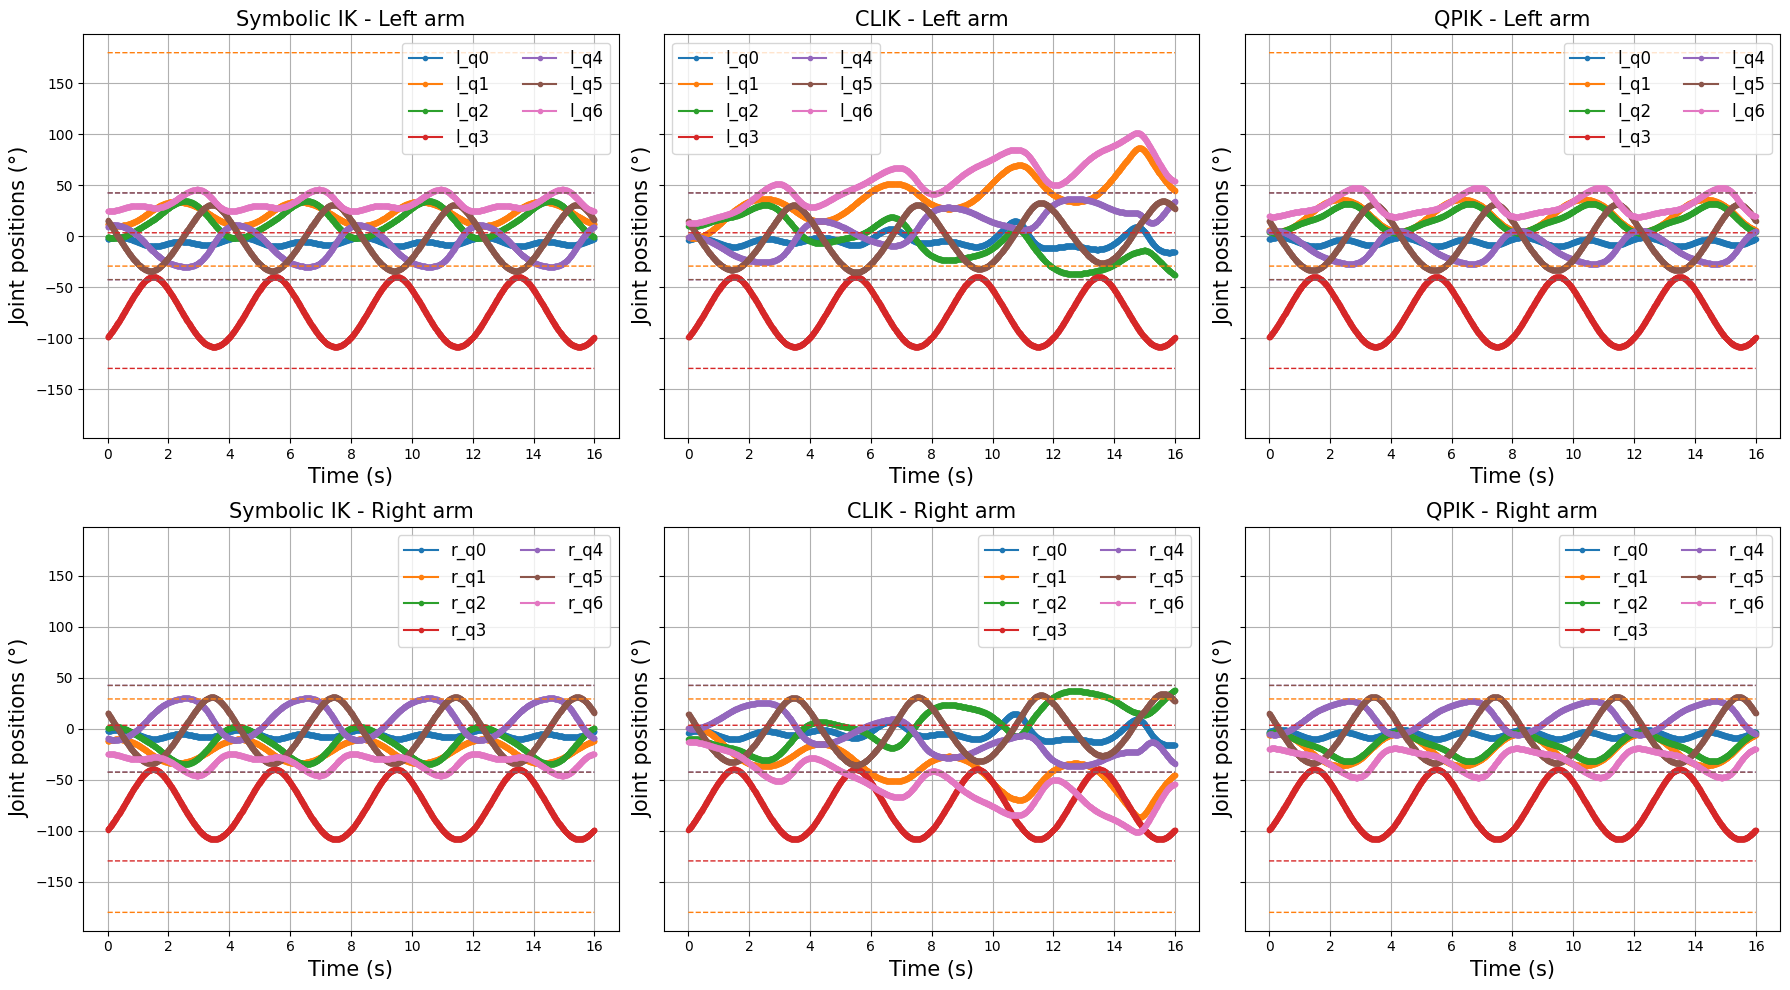

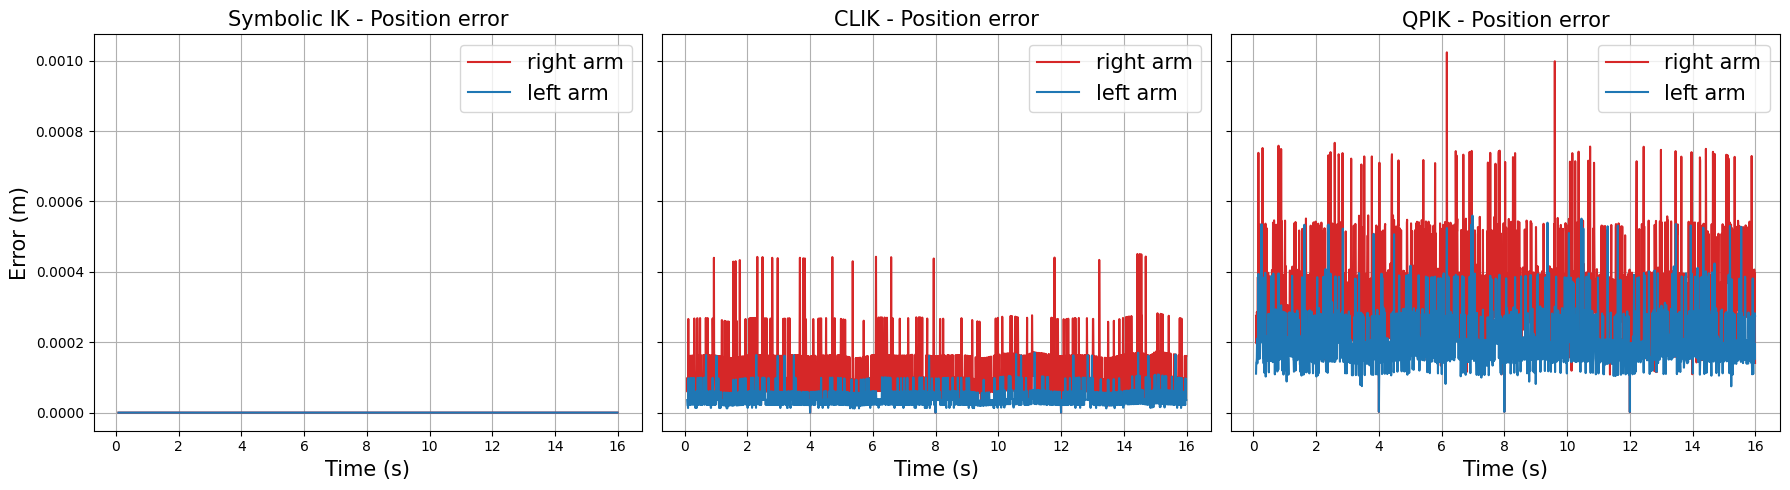

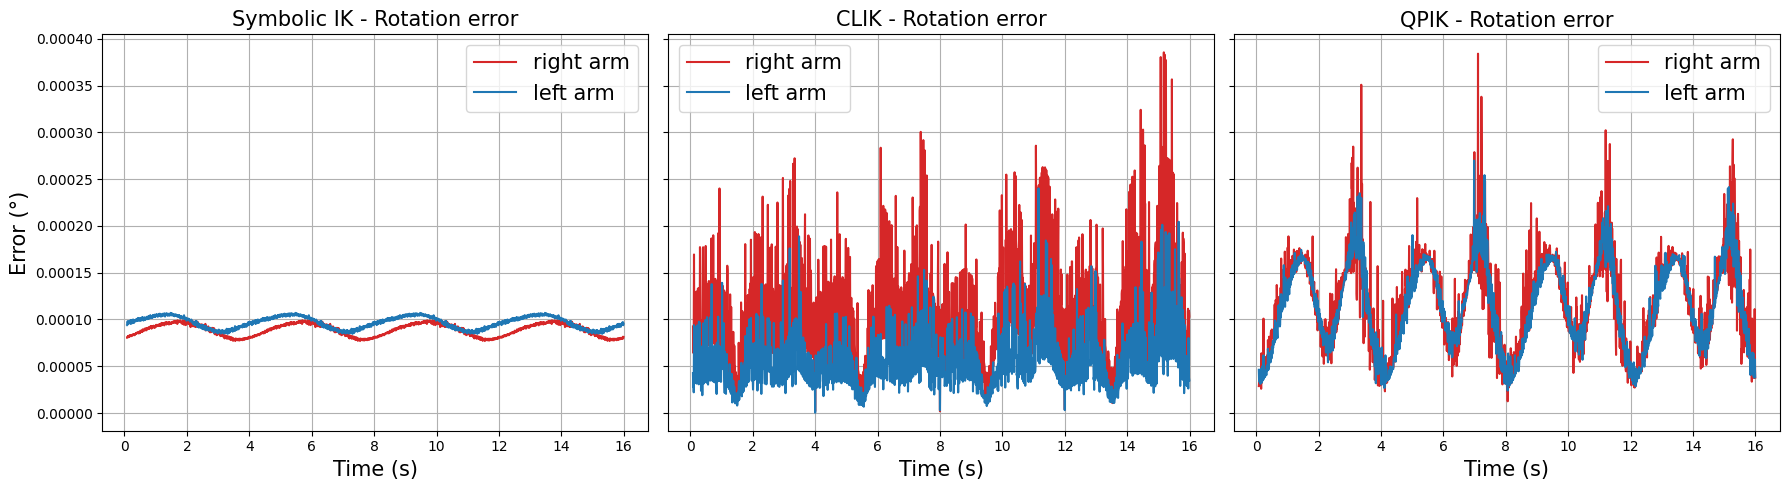

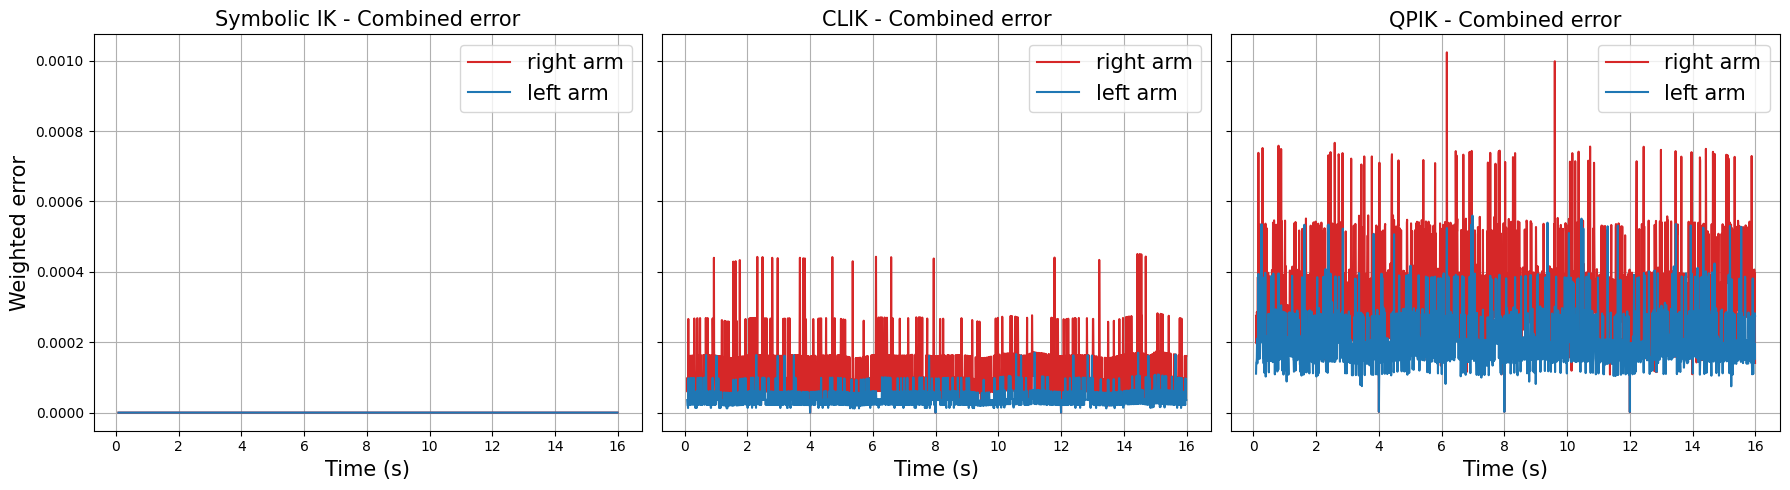

In [17]:
dfs = [(df_sym, "Symbolic IK"), (df_num, "CLIK"), (df_qp, "QPIK")]
l_cols = [f"l_q{i}" for i in range(7)]
r_cols = [f"r_q{i}" for i in range(7)]

time_slice = slice(10, None)
lambda_theta = 1e-6 / np.deg2rad(1) ** 2

q_min_l = np.array([-10000.0, -0.51, -10000.0, -2.26, -0.7417649320975901, -0.7417649320975901, -10000.0])
q_max_l = np.array([10000.0, 3.14, 10000.0, 0.06, 0.7417649320975901, 0.7417649320975901, 10000.0])

q_min_r = np.array([-10000.0, -3.14, -10000.0, -2.26, -0.7417649320975901, -0.7417649320975901, -10000.0])
q_max_r = np.array([10000.0, 0.51, 10000.0, 0.06, 0.7417649320975901, 0.7417649320975901, 10000.0])

q_min_l_deg = np.rad2deg(q_min_l)
q_max_l_deg = np.rad2deg(q_max_l)
q_min_r_deg = np.rad2deg(q_min_r)
q_max_r_deg = np.rad2deg(q_max_r)

skip_idxs = {0, 2, 6}

base_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
colors = [base_colors[i % len(base_colors)] for i in range(7)]

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey="row")

for idx, (df, title) in enumerate(dfs):
    for j, col in enumerate(l_cols):
        axes[0, idx].plot(df["time"], df[col], marker=".", label=col, color=colors[j])
    axes[0, idx].set_title(f"{title} - Left arm", fontsize=15)
    axes[0, idx].set_xlabel("Time (s)", fontsize=15)
    axes[0, idx].set_ylabel("Joint positions (°)", fontsize=15)
    axes[0, idx].grid(True)
    axes[0, idx].legend(ncol=2, fontsize=12)

    for j, col in enumerate(r_cols):
        axes[1, idx].plot(df["time"], df[col], marker=".", label=col, color=colors[j])
    axes[1, idx].set_title(f"{title} - Right arm", fontsize=15)
    axes[1, idx].set_xlabel("Time (s)", fontsize=15)
    axes[1, idx].set_ylabel("Joint positions (°)", fontsize=15)
    axes[1, idx].grid(True)
    axes[1, idx].legend(ncol=2, fontsize=12)

    vals = []
    for j, col in enumerate(l_cols):
        arr = np.asarray(df[col])
        arr = arr[np.isfinite(arr)]
        if arr.size:
            vals.append(arr.min())
            vals.append(arr.max())
    for j, col in enumerate(r_cols):
        arr = np.asarray(df[col])
        arr = arr[np.isfinite(arr)]
        if arr.size:
            vals.append(arr.min())
            vals.append(arr.max())
    for j in range(7):
        if j in skip_idxs:
            continue
        vals.append(q_min_l_deg[j])
        vals.append(q_max_l_deg[j])
        vals.append(q_min_r_deg[j])
        vals.append(q_max_r_deg[j])

    if vals:
        ymin = min(vals)
        ymax = max(vals)
        yrange = ymax - ymin if ymax != ymin else abs(ymax) + 1.0
        pad = 0.05 * yrange
        axes[0, idx].set_ylim(ymin - pad, ymax + pad)
        axes[1, idx].set_ylim(ymin - pad, ymax + pad)

    t = df["time"].values
    for j in range(7):
        if j in skip_idxs:
            continue
        col_color = colors[j]
        axes[0, idx].plot(t, np.full_like(t, q_min_l_deg[j]), linestyle="--", linewidth=1, color=col_color, label="_nolegend_")
        axes[0, idx].plot(t, np.full_like(t, q_max_l_deg[j]), linestyle="--", linewidth=1, color=col_color, label="_nolegend_")
        axes[1, idx].plot(t, np.full_like(t, q_min_r_deg[j]), linestyle="--", linewidth=1, color=col_color, label="_nolegend_")
        axes[1, idx].plot(t, np.full_like(t, q_max_r_deg[j]), linestyle="--", linewidth=1, color=col_color, label="_nolegend_")

fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for idx, (df, title) in enumerate(dfs):
    axes[idx].plot(df["time"][time_slice], df["r_pos_err"][time_slice], label="right arm", color="tab:red")
    axes[idx].plot(df["time"][time_slice], df["l_pos_err"][time_slice], label="left arm", color="tab:blue")
    axes[idx].set_title(f"{title} - Position error", fontsize=15)
    axes[idx].set_xlabel("Time (s)", fontsize=15)
    if idx == 0:
        axes[idx].set_ylabel("Error (m)", fontsize=15)
    axes[idx].legend(fontsize=15)
    axes[idx].grid(True)
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for idx, (df, title) in enumerate(dfs):
    axes[idx].plot(df["time"][time_slice], np.rad2deg(df["r_rot_err"][time_slice]), label="right arm", color="tab:red")
    axes[idx].plot(df["time"][time_slice], np.rad2deg(df["l_rot_err"][time_slice]), label="left arm", color="tab:blue")
    axes[idx].set_title(f"{title} - Rotation error", fontsize=15)
    axes[idx].set_xlabel("Time (s)", fontsize=15)
    if idx == 0:
        axes[idx].set_ylabel("Error (°)", fontsize=15)
    axes[idx].legend(fontsize=15)
    axes[idx].grid(True)
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for idx, (df, title) in enumerate(dfs):
    comb_l = np.sqrt(df["l_pos_err"] ** 2 + (lambda_theta * df["l_rot_err"] ** 2))
    comb_r = np.sqrt(df["r_pos_err"] ** 2 + (lambda_theta * df["r_rot_err"] ** 2))
    axes[idx].plot(df["time"][time_slice], comb_r[time_slice], label="right arm", color="tab:red")
    axes[idx].plot(df["time"][time_slice], comb_l[time_slice], label="left arm", color="tab:blue")
    axes[idx].set_title(f"{title} - Combined error", fontsize=15)
    axes[idx].set_xlabel("Time (s)", fontsize=15)
    if idx == 0:
        axes[idx].set_ylabel("Weighted error", fontsize=15)
    axes[idx].legend(fontsize=15)
    axes[idx].grid(True)
fig.tight_layout()
plt.show()

## 3D Trajectories comparison

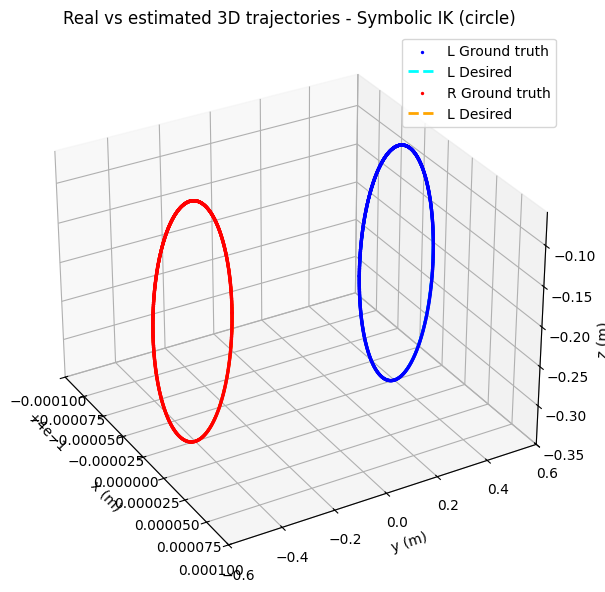

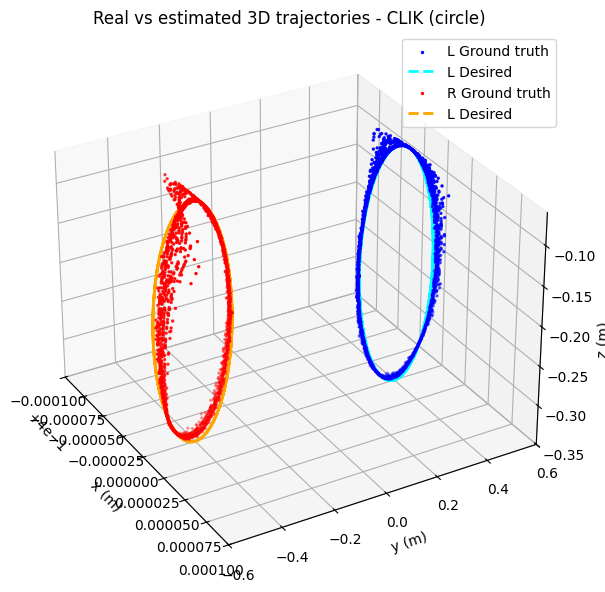

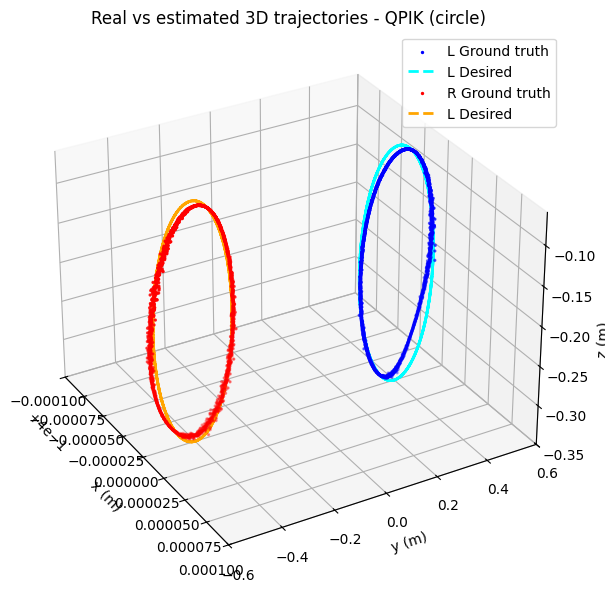

In [18]:
from mpl_toolkits.mplot3d import Axes3D


test = "circle"  # line, circle, heart

filepath_sym = f"data/sym_{test}_data.csv"
filepath_num = f"data/num_{test}_data.csv"
filepath_qp = f"data/qp_{test}_data.csv"

df_sym = pd.read_csv(filepath_sym, sep=",", header=0).copy()
df_num = pd.read_csv(filepath_num, sep=",", header=0).copy()
df_qp = pd.read_csv(filepath_qp, sep=",", header=0).copy()


if test == "line":
    elev = 30
    azim = -30
    xlim = [0.3999, 0.4001]
    ylim = [-0.5, 0.5]
    zlim = [-(2e-1 - 3e-5), -(2e-1 + 3e-5)]
elif test == "heart":
    elev = 30
    azim = -30
    xlim = [0.54999, 0.55001]
    ylim = [-0.4, 0.4]
    zlim = [-0.2, 0.05]
elif test == "circle":
    elev = 30
    azim = -30
    xlim = [0.3999, 0.4001]
    ylim = [-0.6, 0.6]
    zlim = [-0.35, -0.06]


def extract_trajectory(df, col_name):
    xs, ys, zs = [], [], []
    for pose_str in df[col_name]:
        pose = parse_pose_matrix(pose_str)
        x, y, z = pose[:3, 3]
        xs.append(x)
        ys.append(y)
        zs.append(z)
    return xs, ys, zs


for name, df in zip(["Symbolic IK", "CLIK", "QPIK"], [df_sym, df_num, df_qp]):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")
    ax.view_init(elev=elev, azim=azim)

    l_x_gth, l_y_gth, l_z_gth = extract_trajectory(df, "l_real_pose")
    l_x_des, l_y_des, l_z_des = extract_trajectory(df, "l_pose")

    r_x_gth, r_y_gth, r_z_gth = extract_trajectory(df, "r_real_pose")
    r_x_des, r_y_des, r_z_des = extract_trajectory(df, "r_pose")

    ax.scatter(l_x_gth, l_y_gth, l_z_gth, label="L Ground truth", color="blue", s=2)
    ax.plot(l_x_des, l_y_des, l_z_des, label="L Desired", linestyle="--", color="cyan", linewidth=2)

    ax.scatter(r_x_gth, r_y_gth, r_z_gth, label="R Ground truth", color="red", s=2)
    ax.plot(r_x_des, r_y_des, r_z_des, label="L Desired", linestyle="--", color="orange", linewidth=2)

    ax.set_title(f"Real vs estimated 3D trajectories - {name} ({test})")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.set_zlabel("z (m)")
    ax.set_xlim(xlim[0], xlim[1])
    ax.set_ylim(ylim[0], ylim[1])
    ax.set_zlim(zlim[0], zlim[1])

    ax.legend()
    plt.tight_layout()
    ax.grid(True)
    plt.show()